In [1]:
import os
for v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'
# then numpy / xso / ssh imports BELOW this line

In [2]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

In [ ]:
import seasonal_scan_harness as ssh

# loosened floor (surfaced): a -0.001 graze won't discard an otherwise-fine combo;
# genuine runaways still terminate -> has_nan. Workers auto-pin BLAS (reproducible).
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -1e-2}

res = ssh.run_seasonal_scan(
    constructs = ['maranon_ward'],                 # drill our best construct only
    groups     = ['pre+recovery', 'post'],         # the two joint-objective eras
    fish_rates = [0.0, 0.1, 0.2, 0.3, 0.4],        # graded axis (joint pairs pre>=post post-hoc)
    param_grid = {
        'GGE':       [0.25, 0.31, 0.33],           # #2 large-Z   (Stock / Taniguchi / Hansen)
        'mP':        [0.0015, 0.01, 0.02],         # #1/#3 PP+Micro (Taniguchi / mid / Ward; >0.02 collapses)
        'm_Z':       [0.05, 0.10, 0.20],           # #2 large-Z   (low end destabilises -> has_nan filters)
        'KsZ':       [0.15, 0.23, 0.45],           # #1 PP        (Ward / Dutk2020 / Dutk2015a; Type III window)
        'sigma_log': [0.15, 0.20, 0.25],           # #2/#3 kernel width (Mattern / mid / Banas)
    },
    years=60, spinup=15,
    solver_kwargs=SK,
    save_path='seasonal_scan_drill.pkl',
    processes=None,                                # = cpu-1
)
print(res.table().round(3).to_string(index=False))

In [5]:
# reproducibility + reload-sensitivity of run_one for the candidate
import importlib, numpy as np
import seasonal_scan_harness as ssh

def trial(tag):
    spec = ssh.allometry('maranon_ward')
    F = ssh.build_forcings(['pre+recovery'])['pre+recovery']
    c = ssh.run_one(spec, F, fish_rate=0.3, years=60, spinup=15, m_Z=0.1,
                    grazing={'KsZ': 0.23, 'sigma_log': 0.2})
    print(f"{tag:22s} has_nan={c['has_nan']}  mcs={c.get('mcs', float('nan')):.3f}")

print("A) clean module, 3 back-to-back:")
for i in range(3): trial(f"  clean {i+1}")

print("B) after importlib.reload(ssh):")
importlib.reload(ssh)
for i in range(3): trial(f"  reloaded {i+1}")

A) clean module, 3 back-to-back:
  clean 1              has_nan=False  mcs=5.513
  clean 2              has_nan=False  mcs=5.513
  clean 3              has_nan=False  mcs=5.513
B) after importlib.reload(ssh):
  reloaded 1           has_nan=False  mcs=5.513
  reloaded 2           has_nan=False  mcs=5.513
  reloaded 3           has_nan=False  mcs=5.513



 maranon_ward | KsZ=0.23 sigma=0.2 m_Z=0.1 | fish=0.3
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           5.51      8.65      2.97      4.84   -0.36   -0.39
pico         0.496     0.436     0.535     0.429   +0.14   +0.25
nano         0.234     0.217     0.236     0.205   +0.08   +0.15
micro         0.27     0.346     0.213     0.271   -0.22   -0.21
sumP         0.747     0.633     0.562     0.535   +0.18   +0.05
N              1.3      1.46     0.868       1.2   -0.11   -0.27
PP            0.17     0.548     0.151     0.286   -0.69   -0.47
Export        2.67      3.51      2.52      2.68   -0.24   -0.06
Z200        0.0336    0.0504    0.0119    0.0472   -0.33   -0.75
Z500       0.00158    0.0287  5.44e-05    0.0235   -0.95   -1.00
score   mean=0.227  med=0.264  joint(max)=0.264   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.01 Z200_peak=0.128 cv_sumP=0.82
        mcs_peak month  model=4

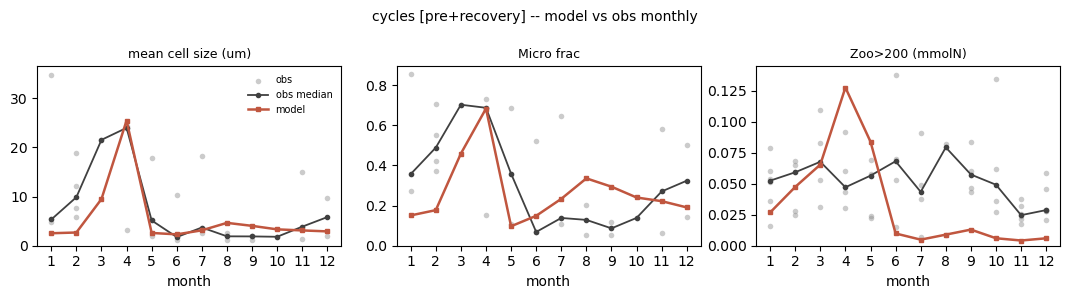

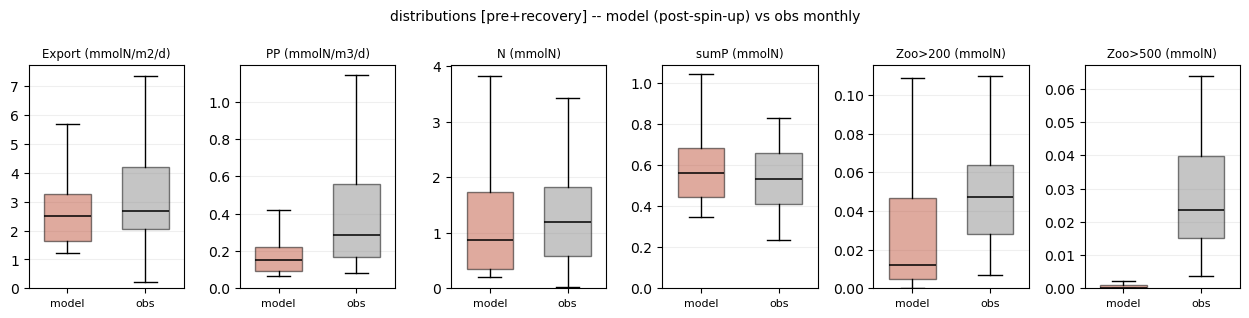

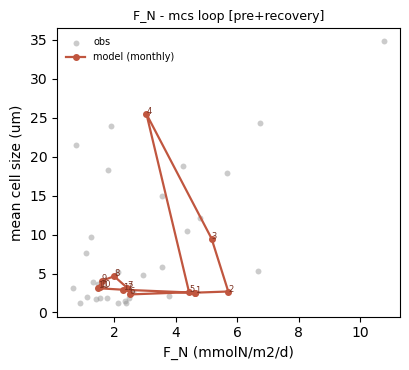


 maranon_ward | KsZ=0.23 sigma=0.2 m_Z=0.1 | fish=0.1
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           2.71      4.88      2.25       2.3   -0.44   -0.02
pico         0.574     0.546     0.591     0.564   +0.05   +0.05
nano         0.252     0.258     0.254     0.264   -0.02   -0.04
micro        0.173     0.196     0.146     0.125   -0.11   +0.16
sumP         0.473     0.589     0.409      0.46   -0.20   -0.11
N            0.712      1.34     0.422      1.09   -0.47   -0.61
PP           0.117     0.323    0.0978     0.202   -0.64   -0.52
Export        2.12      2.73      1.87      2.24   -0.22   -0.17
Z200        0.0198    0.0652   0.00574    0.0549   -0.70   -0.90
Z500       0.00232    0.0357  5.96e-05    0.0331   -0.93   -1.00
score   mean=0.231  med=0.088  joint(max)=0.231   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=0.99 Z200_peak=0.055 cv_sumP=0.33
        mcs_peak month  model=5  obs=1 

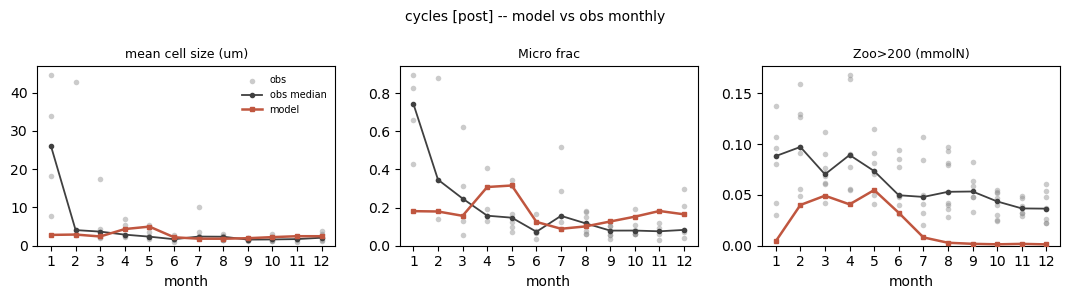

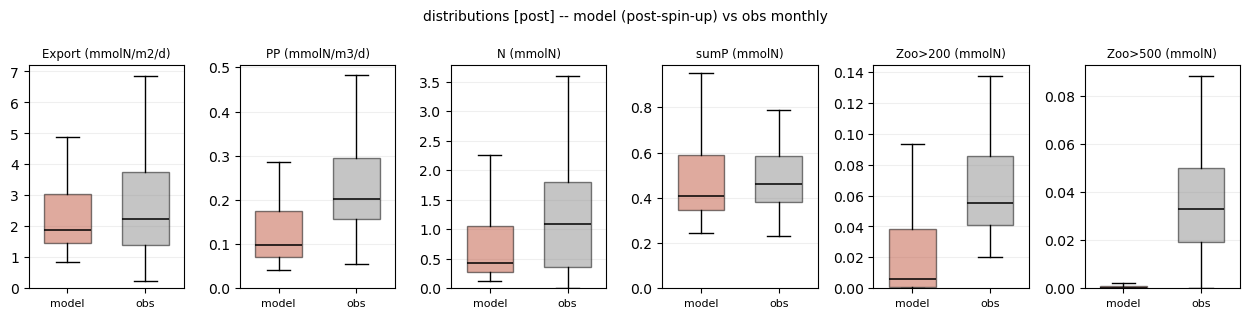

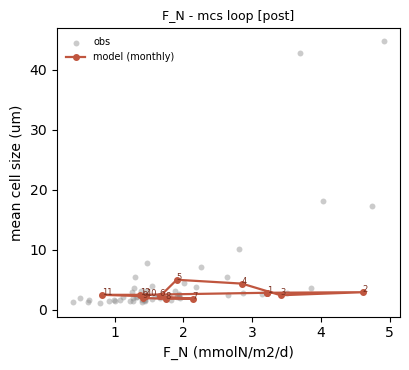

In [4]:
# --- seasonal diagnostic: candidate maranon_ward, graded fish, both eras ---
import importlib
import seasonal_scan_harness as ssh
import seasonal_diagnostics as sd
importlib.reload(ssh); importlib.reload(sd)

GROUPS = ('pre+recovery', 'post')
FISH   = {'pre+recovery': 0.3, 'post': 0.1}        # graded r_F (pre high / post low)
GRZ    = {'KsZ': 0.23, 'sigma_log': 0.2}           # candidate grazing
M_Z, YEARS, SPIN = 0.1, 60, 15

forc  = ssh.build_forcings(GROUPS)
obs_t = ssh.build_obs_targets(GROUPS)
obs_m = ssh.build_obs_monthly(GROUPS)
spec  = ssh.allometry('maranon_ward')

for g in GROUPS:
    clim, r = ssh.run_one(spec, forc[g], fish_rate=FISH[g], years=YEARS, spinup=SPIN,
                          m_Z=M_Z, grazing=GRZ, return_traj=True)
    sd.diagnose(clim, r, group=g, spinup=SPIN, obs_targets=obs_t, obs_monthly=obs_m,
                title=f"\n maranon_ward | KsZ={GRZ['KsZ']} sigma={GRZ['sigma_log']} "
                      f"m_Z={M_Z} | fish={FISH[g]}")